# Scaling: runtime vs number of cells — SingleRust vs scanpy

How does the **core pipeline** (QC → normalize → log1p → HVG → PCA) scale as the cell count
grows? We subsample a CZI CELLxGENE blood dataset to several sizes and, at each size, run the
full pipeline with both SingleRust and scanpy, timing **compute only**.

- SingleRust runs the whole pipeline in one process (`bench_step … all`), feeding each step into
  the next in memory (the in-place pattern) — per-step and total compute times are printed.
- scanpy runs the same five steps on the same raw subsample, timed in-process.

## Setup

In [1]:
import hdf5plugin
import os, sys, subprocess, pathlib, time
import numpy as np, pandas as pd
import scanpy as sc, anndata as ad
import matplotlib.pyplot as plt

ROOT = pathlib.Path.cwd()
if ROOT.name == "demo":
    ROOT = ROOT.parent
DATA = ROOT / "data"; DATA.mkdir(exist_ok=True)
BENCH_INPUT = DATA / "bench_input.h5ad"
N_BASE = 50_000
SIZES = [3_000, 6_000, 12_500, 25_000, 50_000]   # cells-vs-runtime sweep points
SEED = 0

ENV = dict(os.environ)
ENV["PATH"] = "/opt/homebrew/bin:" + str(pathlib.Path.home()/".cargo"/"bin") + ":" + ENV.get("PATH","")
BIN = ROOT / "target" / "release" / "examples" / "bench_step"

import multiprocessing; print("CPU cores:", multiprocessing.cpu_count())
subprocess.run(["cargo","build","--release","--features","enrichment","--example","bench_step"],
               cwd=ROOT, env=ENV, check=True, capture_output=True, text=True)

def rust_all(path):
    # Run the full Rust pipeline once; return {step: seconds, ..., 'total': seconds}.
    p = subprocess.run([str(BIN), str(path), "all", "-"], cwd=ROOT, env=ENV,
                       capture_output=True, text=True)
    if p.returncode:
        print(p.stdout[-800:]); print(p.stderr[-1500:]); raise RuntimeError("rust all failed")
    out = {}
    for line in p.stdout.splitlines():
        k, _, v = line.partition("=")
        if k.startswith("ALL_"): out[k[4:]] = float(v)
        elif k == "STEP_SECONDS": out["total"] = float(v)
    return out

def scanpy_all(a):
    # Same five steps, timed individually; returns {step: seconds, ..., 'total': seconds}.
    a.var["mt"] = a.var_names.str.upper().str.startswith("MT-")
    t = {}
    def step(name, fn):
        s = time.perf_counter(); fn(); t[name] = time.perf_counter() - s
    step("qc", lambda: sc.pp.calculate_qc_metrics(a, qc_vars=["mt"], percent_top=[50,100,200,500],
                                                  log1p=True, inplace=True))
    step("normalize", lambda: sc.pp.normalize_total(a, target_sum=1e4))
    step("log1p", lambda: sc.pp.log1p(a))
    step("hvg", lambda: sc.pp.highly_variable_genes(a, n_top_genes=2000, flavor="seurat"))
    step("pca", lambda: sc.pp.pca(a, n_comps=50, svd_solver="randomized",
                                  use_highly_variable=True, random_state=42))
    t["total"] = sum(t.values())
    return t

CPU cores: 18


## Load the base dataset (raw counts)

In [2]:
if not BENCH_INPUT.exists():
    subprocess.run([sys.executable, str(ROOT/"demo"/"prepare_data.py"),
                    "--n-cells", str(N_BASE), "--per-type", "2000", "--out", str(BENCH_INPUT)],
                   check=True)
raw = ad.read_h5ad(BENCH_INPUT)
print(raw.shape)

(50000, 35507)


## Sweep cell counts

At each size we write a raw-counts subsample for the Rust binary and run both pipelines. The
full 50k uses the base file directly (no resampling).

In [3]:
rng = np.random.default_rng(SEED)

# Warm-up (untimed): scanpy's HVG/PCA paths JIT-compile and spin up thread pools on first call.
# Run both pipelines once on a tiny subsample so the first *timed* size isn't penalized.
_warm = raw[np.sort(rng.choice(raw.n_obs, size=min(800, raw.n_obs), replace=False))].copy()
scanpy_all(_warm.copy())
_wp = DATA / "scale_warmup.h5ad"; _warm.write_h5ad(_wp); rust_all(_wp)
print("warm-up done")

rows = []  # long form: n_cells, impl, step, seconds
for n in SIZES:
    if n >= raw.n_obs:
        sub, path = raw, BENCH_INPUT
    else:
        idx = np.sort(rng.choice(raw.n_obs, size=n, replace=False))
        sub = raw[idx].copy()
        path = DATA / f"scale_{n}.h5ad"
        sub.write_h5ad(path)
    rt = rust_all(path)
    st = scanpy_all(sub.copy())
    for step in ["qc","normalize","log1p","hvg","pca","total"]:
        rows.append(dict(n_cells=n, impl="SingleRust", step=step, seconds=rt[step]))
        rows.append(dict(n_cells=n, impl="scanpy", step=step, seconds=st[step]))
    print(f"{n:6d} cells | scanpy {st['total']:6.2f}s | rust {rt['total']:6.2f}s "
          f"| speedup {st['total']/rt['total']:4.2f}×")
df = pd.DataFrame(rows)

/Users/iandriver/Downloads/SingleRust/.venv/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)
/Users/iandriver/Downloads/SingleRust/.venv/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:273: UserWarning: svd_solver 'randomized' does not work with sparse input. Densifying the array. This may take a very large amount of memory.
  warnings.warn(


warm-up done


/Users/iandriver/Downloads/SingleRust/.venv/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)
/Users/iandriver/Downloads/SingleRust/.venv/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:273: UserWarning: svd_solver 'randomized' does not work with sparse input. Densifying the array. This may take a very large amount of memory.
  warnings.warn(


  3000 cells | scanpy   1.80s | rust   0.21s | speedup 8.50×


/Users/iandriver/Downloads/SingleRust/.venv/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)
/Users/iandriver/Downloads/SingleRust/.venv/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:273: UserWarning: svd_solver 'randomized' does not work with sparse input. Densifying the array. This may take a very large amount of memory.
  warnings.warn(


...

 12500 cells | scanpy   5.59s | rust   0.69s | speedup 8.07×


/Users/iandriver/Downloads/SingleRust/.venv/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)
/Users/iandriver/Downloads/SingleRust/.venv/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:273: UserWarning: svd_solver 'randomized' does not work with sparse input. Densifying the array. This may take a very large amount of memory.
  warnings.warn(


 25000 cells | scanpy   6.12s | rust   1.35s | speedup 4.52×


/Users/iandriver/Downloads/SingleRust/.venv/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)
/Users/iandriver/Downloads/SingleRust/.venv/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:273: UserWarning: svd_solver 'randomized' does not work with sparse input. Densifying the array. This may take a very large amount of memory.
  warnings.warn(


 50000 cells | scanpy   7.77s | rust   2.62s | speedup 2.97×


## Total runtime vs cell count

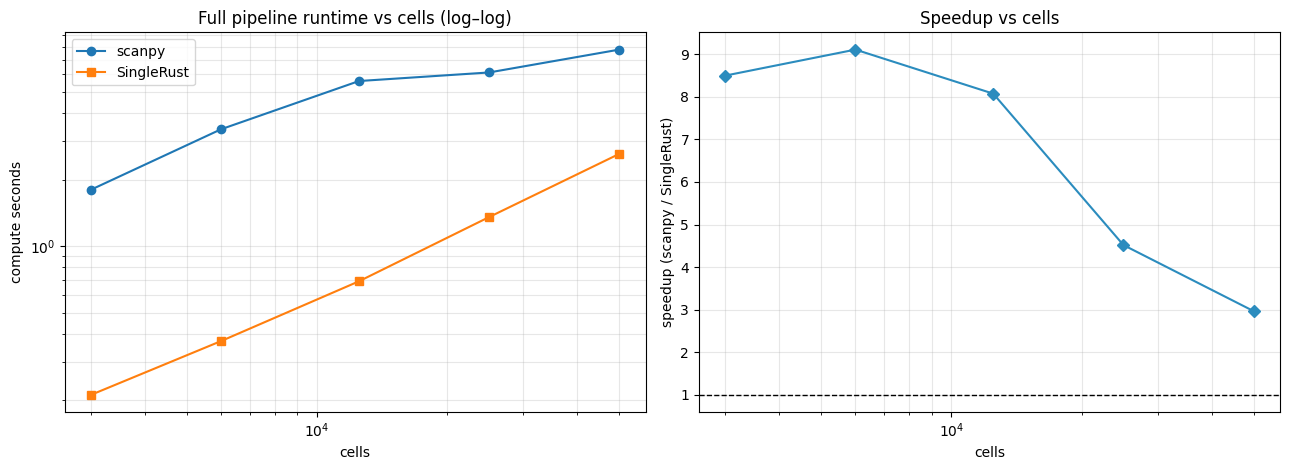

impl,SingleRust,scanpy,speedup
n_cells,,,
3000,0.212,1.801,8.499
6000,0.371,3.384,9.110
12500,0.693,5.594,8.075
25000,1.354,6.118,4.519
50000,2.617,7.766,2.967


In [4]:
tot = df[df.step=="total"].pivot(index="n_cells", columns="impl", values="seconds")
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
ax[0].plot(tot.index, tot["scanpy"], "o-", label="scanpy")
ax[0].plot(tot.index, tot["SingleRust"], "s-", label="SingleRust")
ax[0].set(xscale="log", yscale="log", xlabel="cells", ylabel="compute seconds",
          title="Full pipeline runtime vs cells (log–log)")
ax[0].legend(); ax[0].grid(True, which="both", alpha=.3)

speedup = tot["scanpy"] / tot["SingleRust"]
ax[1].plot(speedup.index, speedup.values, "D-", color="#2b8cbe")
ax[1].axhline(1.0, color="k", lw=1, ls="--")
ax[1].set(xscale="log", xlabel="cells", ylabel="speedup (scanpy / SingleRust)",
          title="Speedup vs cells")
ax[1].grid(True, which="both", alpha=.3)
plt.tight_layout(); plt.show()
tot.assign(speedup=speedup).style.format("{:.3f}")

## Per-step scaling

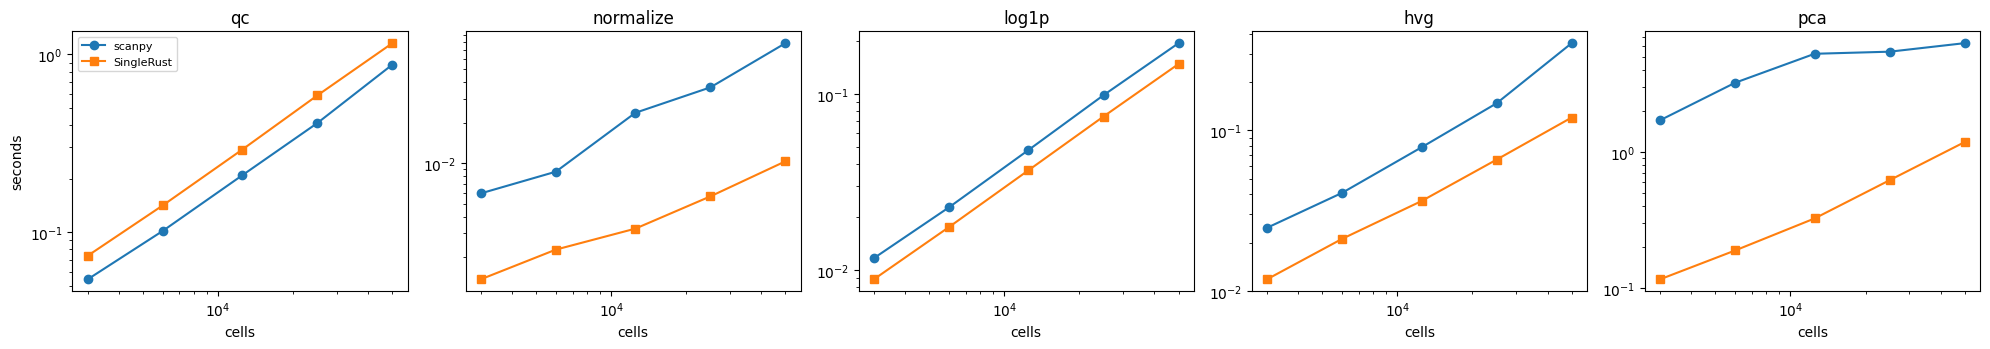

In [5]:
steps = ["qc","normalize","log1p","hvg","pca"]
fig, axes = plt.subplots(1, len(steps), figsize=(4*len(steps), 3.6), sharex=True)
for ax, step in zip(axes, steps):
    d = df[df.step==step].pivot(index="n_cells", columns="impl", values="seconds")
    ax.plot(d.index, d["scanpy"], "o-", label="scanpy")
    ax.plot(d.index, d["SingleRust"], "s-", label="SingleRust")
    ax.set(xscale="log", yscale="log", title=step, xlabel="cells")
axes[0].set_ylabel("seconds"); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Notes

- Compute time only (Rust `.h5ad` read/write excluded); both sides use all cores.
- Each size runs both pipelines on the **same** raw subsample. Single run per size — indicative.
- ORA is omitted here (no scanpy equivalent); see `scverse_benchmark.ipynb` for the per-step
  head-to-head including ORA.